In [1]:
# imports

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

# set style of visualization

sns.set_style("whitegrid")
sns.set_palette("RdBu")


In [2]:
# loading data 

data_path = ("./Student_Performance.csv")
data = pd.read_csv(data_path)


In [3]:
# how many rows&columns does your dataset have

data.shape

(10000, 6)

In [4]:
# print a pd dataframe of the different columns of your data with their respective names

data.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='str')

In [5]:
# show the top 5 rows of your data

data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [6]:
# visualize a dataframe of the different columns and their respective data type

data.dtypes.to_frame("data type")

,data type
Hours Studied,int64
Previous Scores,int64
Extracurricular Activities,str
Sleep Hours,int64
Sample Question Papers Practiced,int64
Performance Index,float64


In [7]:
# get some statistical info of your data's numerical columns

data.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [8]:
# we can also see some statistical values of our non-numerical columns 

data.describe(include=object)

C:\Users\saver\AppData\Local\Temp\ipykernel_33236\823433981.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=object)


,Extracurricular Activities
count,10000
unique,2
top,No
freq,5052


In [9]:
# drop every duplicate row from our data 

'''data.drop_duplicates(inplace=True)
data.reset_index(drop=True , inplace=True) #this rearranges the columns after dropping duplicates

data'''


'data.drop_duplicates(inplace=True)\ndata.reset_index(drop=True , inplace=True) #this rearranges the columns after dropping duplicates\n\ndata'

<span style="color:#ED5337;">I have commented that code because I made a mistake, after checking some resources I realised that directly deleting duplicates is a mistake, at first glance it might look like the data has got duplicates but in reality it does not </span>

In [10]:
data.duplicated().any()

np.True_

In [11]:
#null count and percentage of null values of each column

null_summary = pd.DataFrame({
    "Null Count": data.isnull().sum(),
    "Null Percentage": data.isnull().mean() * 100
})
null_summary


,Null Count,Null Percentage
Hours Studied,0,0.0
Previous Scores,0,0.0
Extracurricular Activities,0,0.0
Sleep Hours,0,0.0
Sample Question Papers Practiced,0,0.0
Performance Index,0,0.0


In [12]:
# lets discover the 'Hours Studied' column

data["Hours Studied"].unique()

array([7, 4, 8, 5, 3, 6, 2, 1, 9])

In [13]:
def count_plot(column_name , hue=None , rotation = 0):

    """

sns.countplot() mainly needs data and x:
- data specifies the DataFrame.
- x specifies the categorical column to count.

hue and order are optional:
- hue splits each category based on another categorical column for comparison.
- order controls the order of the categories. Here, value_counts() sorts them
  from most frequent to least frequent, and .index takes the category names.

The loop below then displays the count on top of each bar.

    """

    graph = sns.countplot(
        data = data , # MANDATORY PARAMETER
        x = column_name , # MANDATORY PARAMETER
        hue = hue , 
        order = data[column_name].value_counts().index ,
    )
    
    for container in graph.containers:
        graph.bar_label(container) 
        
        '''bar_label() is a Matplotlib function that looks at every bar inside that container, 
           gets its height, and writes that value on the graph.'''

    plt.xticks(rotation = rotation)
    plt.show()

<span style="color:yellow;">this function above gives us a moderate ordered histogram of how many times each category of our column appears in the dataframe </span>

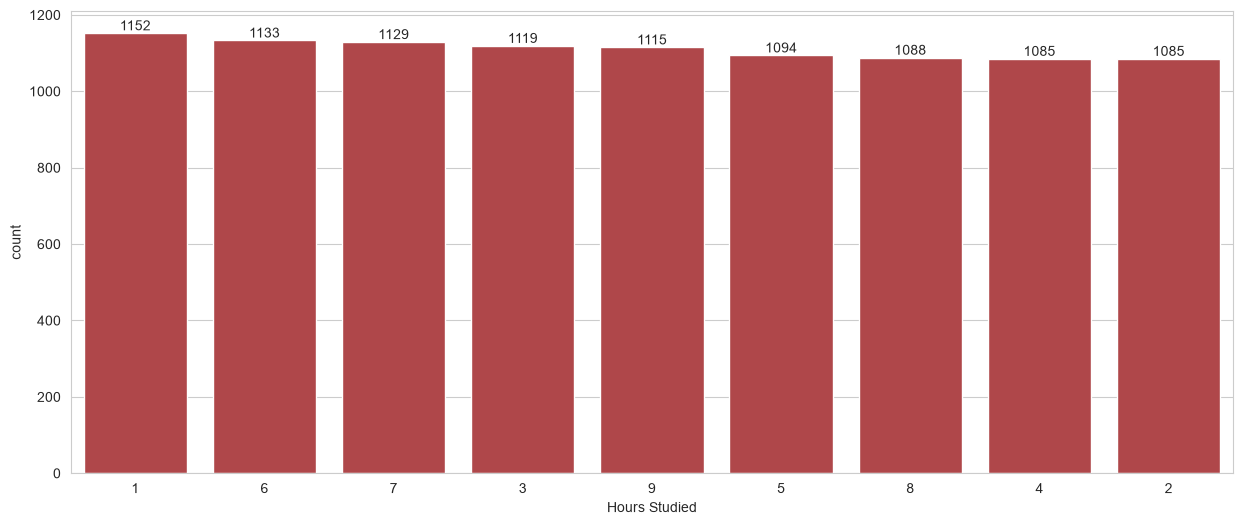

In [14]:
plt.figure(figsize=(15,6))

count_plot(column_name="Hours Studied")

Most students studied 1 hour.

- We can see that the 'Hours Studied' distribution is almost uniform, with no noticeable skewness or outliers.

<span style="color:royalblue;">what is the use of histograms anyway</span>

histograms basically try to answer this question: How are the values of one numerical variable distributed? 

- 1 Symmetric: a distribution is roughly symmetric if the left side is equal to the right side, a normal distribution for example is symmetric 

- 2 Skewed: 
Right-skewed is when your data values are relatively low but a small amount of huge values that are too big compared to the ordinary values stretch your mean off making it big even though the values are not that big, this results in a bigger standard deviation and a median < mean 
Left-skewed is when your data values are relatively high but a small amount of very small values that are too small compared to the ordinary values stretch your mean off making it small even though the values are not that small, this results in a bigger standard deviation and a median > mean 
outliers are the are the cause of skewness

- 3 Uniform (our distributions are uniform):
no region dominates heavily, no symmetry, no skewness, no value is particularly high or low, observations are roughly evenly distributed; its not saying all observations are equal but tiny differences like the ones in our distributions wont really make a difference 

we'll leave it here for now, there are multiple more possible distributions but further understanding will come with more projects 

In [15]:
# lets create a function that uses boxplot to visualize numeric values

def box_plot(x_axis=None , y_axis=None , hue=None , col=None):
    sns.catplot(
                x=x_axis,
                y=y_axis,
                data=data,
                hue=hue, 
                kind='box',
                col=col 
               )

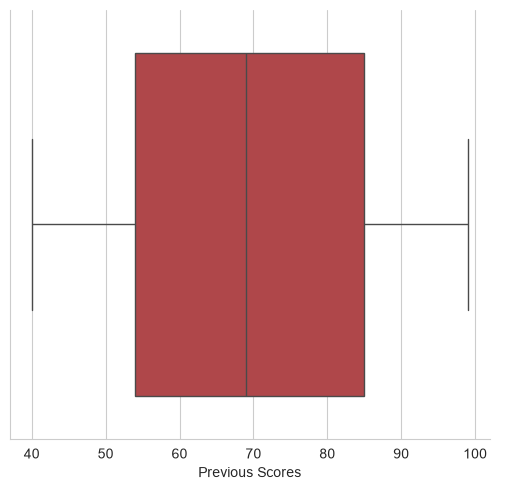

In [16]:
# lets discover the "Previous Scores" column 
''' I will not use a histogram here because previous scores column has way too many values '''

box_plot(x_axis="Previous Scores")

In [17]:
Q1 = data["Previous Scores"].quantile(0.25)
Q2 = data["Previous Scores"].quantile(0.5)
Q3 = data["Previous Scores"].quantile(0.75)

print(f"the average student score is {data["Previous Scores"].mean()}")
print(f"25% of Previous scores are at or below {Q1} ")
print(f"50% of Previous scores are at or below {Q2} ")
print(f"75% of Previous scores are at or below {Q3} ")


the average student score is 69.4457
25% of Previous scores are at or below 54.0 
50% of Previous scores are at or below 69.0 
75% of Previous scores are at or below 85.0 


In [18]:
# lets discover the "Extracurricular Activities" column 

data["Extracurricular Activities"].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [19]:
data["Extracurricular Activities"].value_counts()

Extracurricular Activities
No     5052
Yes    4948
Name: count, dtype: int64

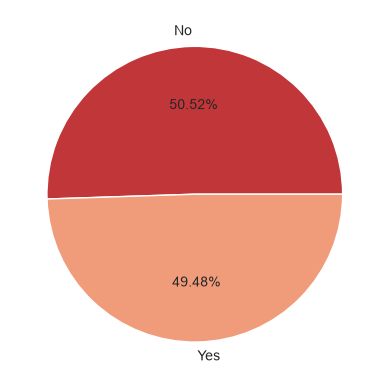

In [20]:
plt.pie(
    (data["Extracurricular Activities"].value_counts()) , 
    labels=(data["Extracurricular Activities"].value_counts().index),
    autopct=lambda percentage: f"{percentage:.2f}%"
       )

- we can see that most students do not participate in extracurricular activities
although the proportions are very close so we could say its a 50/50
- <span style="color:yellow;">we could also use a histogram here, a pie works well when your column only has two values</span>

In [21]:
# lets discover the sleep hours column 

data["Sleep Hours"].unique()

array([9, 4, 7, 5, 8, 6])

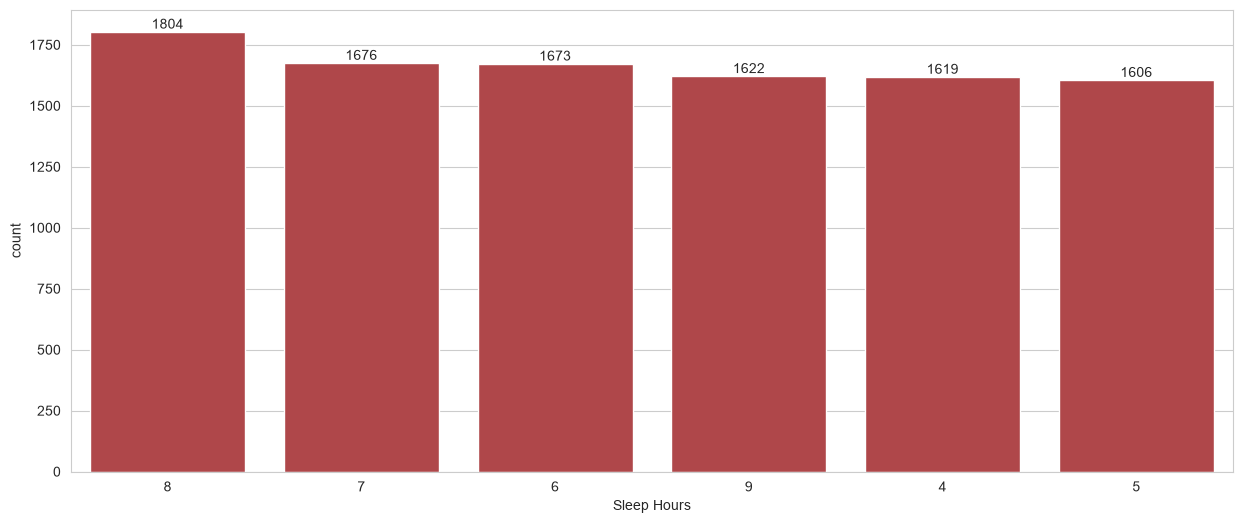

In [22]:
plt.figure(figsize=(15,6))

count_plot(column_name="Sleep Hours")

- again, an almost uniform distribution
- most students are getting 8 hours of sleep

In [23]:
# discovering sample papers practiced column 

data["Sample Question Papers Practiced"].unique()

array([1, 2, 5, 6, 0, 8, 3, 4, 9, 7])

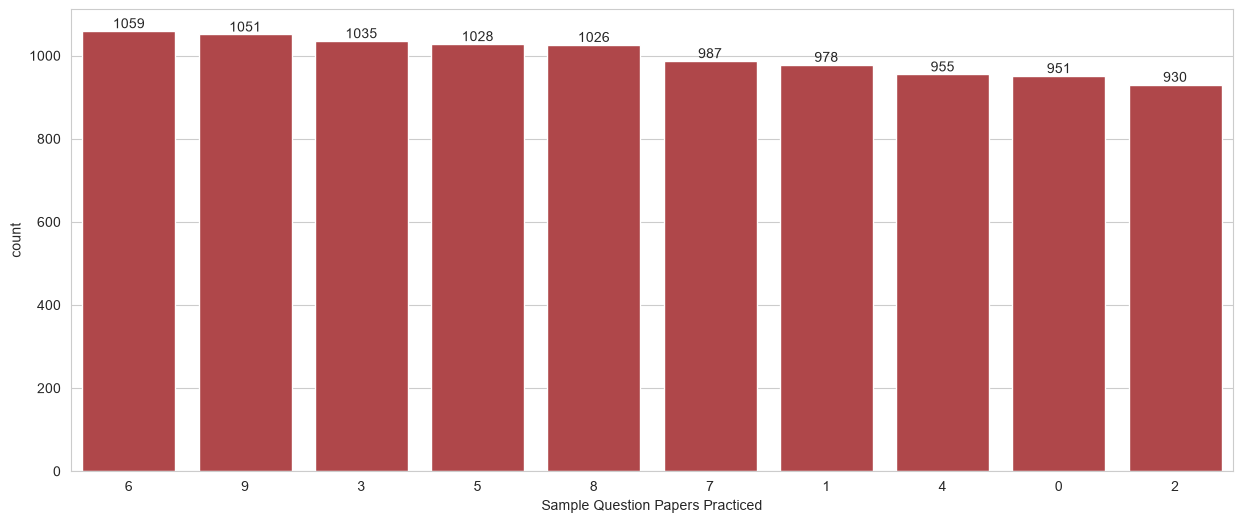

In [24]:
plt.figure(figsize=(15,6))

count_plot(column_name="Sample Question Papers Practiced")

- most students have practiced 6 sample question papers, again an almost uniform distribution

In [25]:
# creating a DataFrame of only numerical values

numerical_data = data[(column for column in data.columns if (data[column].dtype=="int64" or data[column].dtype=="float64"))]
numerical_data.columns

Index(['Hours Studied', 'Previous Scores', 'Sleep Hours',
       'Sample Question Papers Practiced', 'Performance Index'],
      dtype='str')

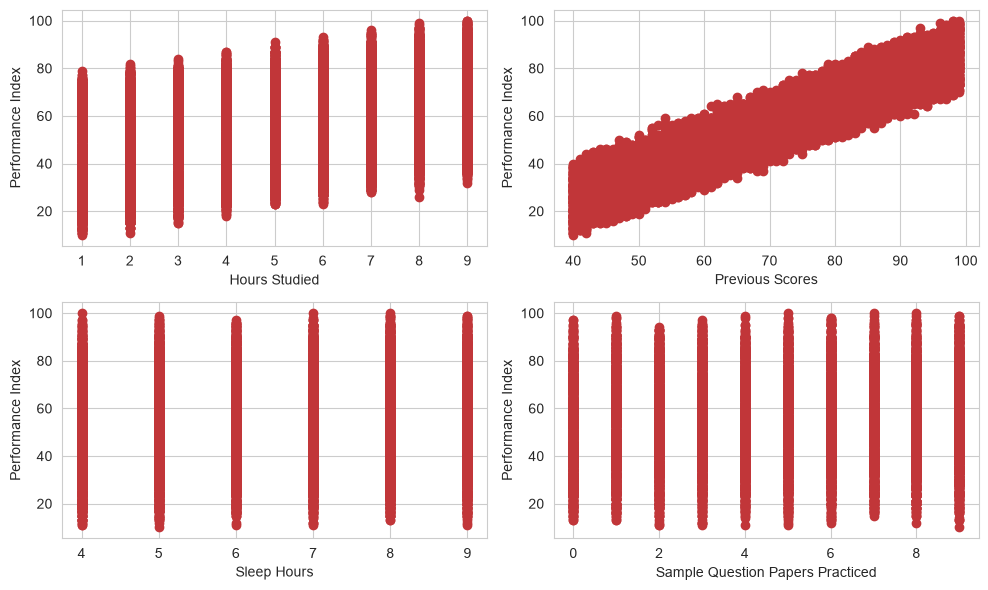

In [26]:
# let's study each numerical column and its distribution with Performance Index

fig , axes = plt.subplots(2,2,
                        figsize=(10,6))
for col,ax in zip(numerical_data.iloc[:,:-1].columns , axes.flat):
    ax.scatter(numerical_data[col] ,
            data["Performance Index"])
    ax.set_xlabel(col)
    ax.set_ylabel("Performance Index")
plt.tight_layout()
plt.show()

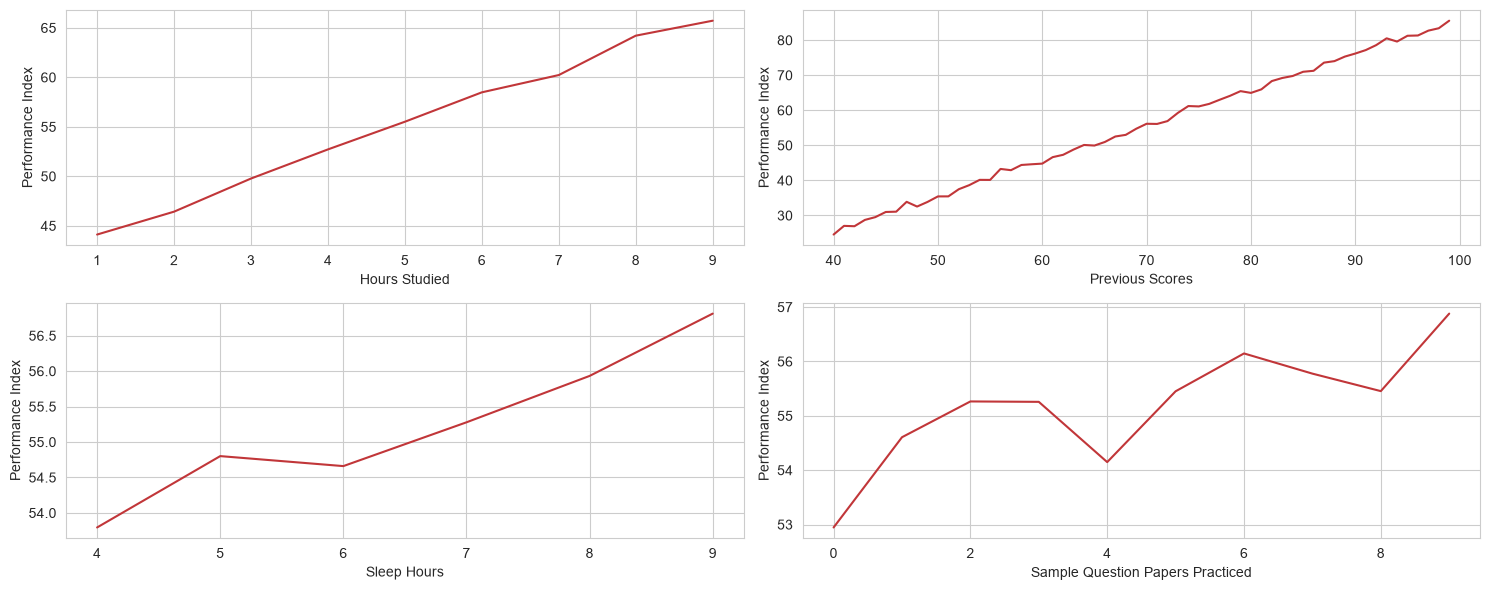

In [27]:
# how does the "Performance Index" mean vary from value to value in each column ? 

fig , axes = plt.subplots(2,2,
                        figsize=(15,6))
for col,ax in zip(numerical_data.iloc[:,:-1].columns , axes.flat):
    column_avg_vs_performance = numerical_data.groupby(col)["Performance Index"].mean()
    ax.plot(column_avg_vs_performance.index ,
            column_avg_vs_performance.values)
    ax.set_xlabel(col)
    ax.set_ylabel("Performance Index")
plt.tight_layout()
plt.show()

from both of the last figures, we can conclude that Previous Scores show the strongest positive relationship with Performance Index, followed by Hours Studied. In comparison, Sleep Hours and the number of Sample Question Papers Practiced show only a weak relationship with performance.

In [28]:
# let's visualize a dataframe of how many students scored above average and below average for each value of Hours Studied

threshold = data["Performance Index"].mean()

summary = data.groupby("Hours Studied")["Performance Index"].agg(
    Mean="mean",
    Variance="var",
    Below_Average=lambda x: (x < threshold).sum(),
    Above_Average=lambda x: (x > threshold).sum()
)

summary

,Mean,Variance,Below_Average,Above_Average
Hours Studied,,,,
1,44.116319,328.438239,775,377
2,46.428571,311.566157,701,384
3,49.776586,306.459881,658,461
4,52.719816,329.260908,584,501
5,55.516453,309.869354,548,546
6,58.486320,314.677595,509,624
7,60.233835,318.539244,474,655
8,64.211397,318.507248,396,692
9,65.725561,321.093377,394,721


In [29]:
Correlation_hoursStudied_PerformanceIndex = data["Hours Studied"].corr(data["Performance Index"])
Correlation_hoursStudied_PerformanceIndex

np.float64(0.37373035069872373)

<span style="color:royalblue;">Lets just calculate the correlation between each column and the performance index</span>

In [30]:
correlation_matrix = data.select_dtypes(exclude=object).corr()
correlation_matrix

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000


<span style="color:yellow;">let's visualize a heatmap of correlations</span>

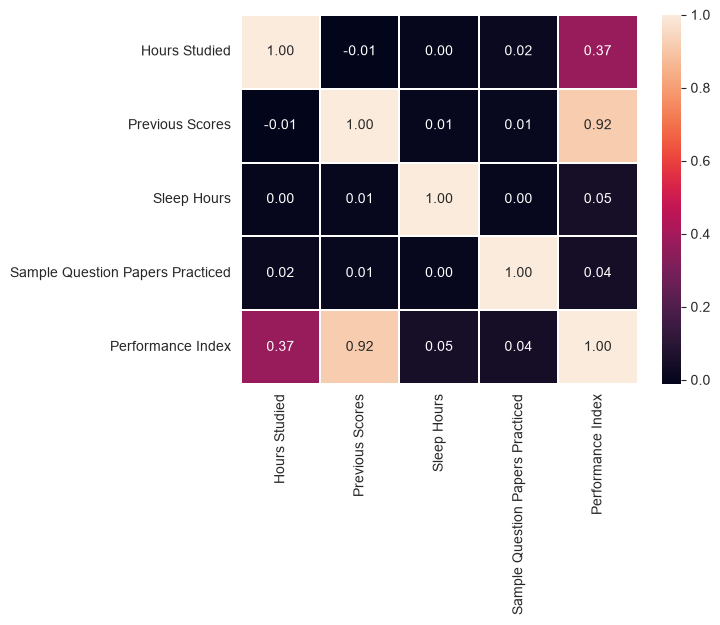

In [31]:
plt.Figure(figsize=(10,6))
sns.heatmap(
            data.select_dtypes(exclude=object).corr() , 
            annot=True , 
            fmt=".2f" , 
            linewidths=0.2
            )
plt.show()

In [32]:
high_study_hours = data["Hours Studied"].quantile(0.75)
# this result is basically saying 75% of students studied 7 hours or less
low_study_hours = data["Hours Studied"].quantile(0.25)
# this result is basically saying 25% of students studied 3 hours or less

print(f"75% of students studied {high_study_hours} hours or less \n25% of students studied {low_study_hours} hours or less")


75% of students studied 7.0 hours or less 
25% of students studied 3.0 hours or less


In [33]:
high_previous_scores = data["Previous Scores"].quantile(0.75)
low_previous_scores = data["Previous Scores"].quantile(0.25)

high_previousScores_bad_performance = data[
    (data["Previous Scores"] >= high_previous_scores) &
    (data["Performance Index"] < threshold)
]

high_previousScores_bad_performance

#this guy was probably the only exception affected by low hours studied and low sleep, he's only 0.2 below average

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
5330,1,86,No,4,9,55.0


In [34]:
low_previous_good_performance = data[
    (data["Previous Scores"] <= low_previous_scores) &
    (data["Performance Index"] > threshold)
]

low_previous_good_performance

#pretty normal results  

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
684,8,54,No,9,7,57.0
5174,9,53,No,9,7,56.0
7468,9,54,No,8,1,59.0


Before moving on to the model, we need to convert "Extracuriccular activities" column to a numerical one 

In [35]:
# before training our model, we need to convert non-numerical columns to numerical

data["Extracurricular Activities"] = data["Extracurricular Activities"].map({
    "Yes":1,
    "No":0
})


In [36]:
X = data.iloc[: , :-1]
Y = data.iloc[: , -1]
X.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5


In [37]:
Y.head()

0    91.0
1    65.0
2    45.0
3    36.0
4    66.0
Name: Performance Index, dtype: float64

<span style="color:royalblue;">Let us split our data</span>

In [38]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X ,
                                                  Y ,
                                                  test_size=0.2 ,
                                                  random_state=42
                                                )
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)


(8000, 5)
(2000, 5)
(8000,)
(2000,)


In [39]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train , Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[2.85,1.02,0.61,0.48,0.19]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Hours Studied','Previous Scores','Extracurricular Activities', 'Sleep Hours','Sample Question Papers Practiced']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-33.92
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


<span style="color:royalblue;">what is the W predicted for each column by our model</span>

In [40]:
coefficients = pd.Series(
    model.coef_,
    index=X.columns
)

coefficients

Hours Studied                       2.852484
Previous Scores                     1.016988
Extracurricular Activities          0.608617
Sleep Hours                         0.476941
Sample Question Papers Practiced    0.191831
dtype: float64

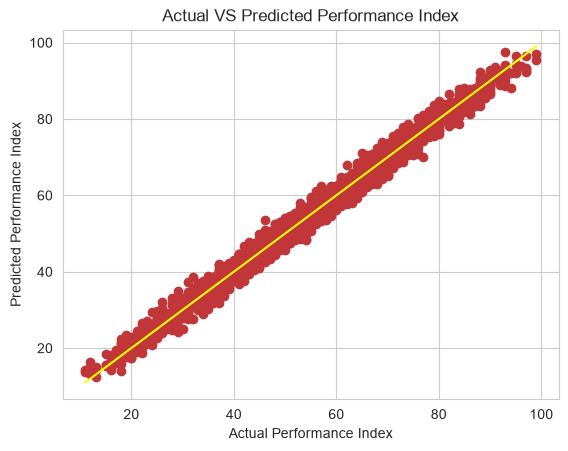

In [41]:
predictions = model.predict(X_test)

plt.scatter(Y_test 
            , predictions)

minimum = min(Y_test.min() , predictions.min())
maximum = max(Y_test.max() , predictions.max())

plt.plot(
    [minimum , maximum],
    [minimum , maximum],
    color="yellow",
    linestyle="-"
)

plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual VS Predicted Performance Index")
plt.show()

Model Evaluation
   - MAE
   - MSE / RMSE
   - R²


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(Y_test, predictions)
mse = mean_squared_error(Y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.6111213463123044
MSE: 4.082628398521853
RMSE: 2.0205515085050054
R²: 0.9889832909573145


MAE = 1.64: this means our predictions are 1.6Performance Index away from the actual value 
MSE = 4.305: is basically MAE but squaring every error before averaging it, which makes it very sensible to huge errors
RMSE is just the root of MSE 
and finally R2

R2 answers the following question: how much is our model better compared to simply predicting the mean as y_test 
Note that a good R2 is not necessarily always a good model 

<span style="color:yellow;">MAE and RMSE being reasonably close means our model is not making huge errors</span>

<span style="color:royalblue;">Residual=yactual​−ypredicted​</span>

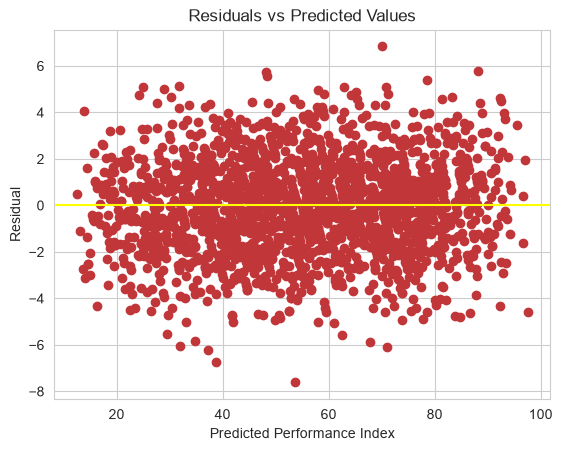

In [43]:
residuals = Y_test - predictions
plt.scatter(predictions, residuals)

plt.axhline(
    y=0,
    color="yellow",
    linestyle="-"
)

plt.xlabel("Predicted Performance Index")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")

plt.show()

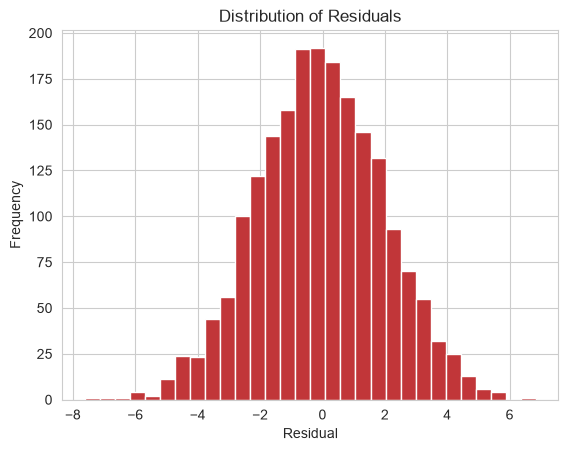

In [44]:
plt.hist(residuals,
          bins=30
        )

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()

CONCLUSION: 

The linear regression model achieved very strong predictive performance, with an MAE of approximately 1.65, meaning predictions were on average about 1.65 Performance Index points away from the actual values. The RMSE was approximately 2.08, which is relatively close to the MAE, suggesting that large prediction errors were uncommon. The model achieved an R² of 0.9884, meaning it explained approximately 98.84% of the variance in Performance Index on the test set.

During EDA, Previous Scores showed by far the strongest individual linear relationship with Performance Index (r ≈ 0.915), while Hours Studied showed a moderate positive relationship (r ≈ 0.375). Sleep Hours, Extracurricular Activities, and Sample Question Papers Practiced individually showed very weak correlations with Performance Index. The input features also showed almost no correlation with each other.

The fitted regression model showed positive coefficients for all five features. Residual analysis showed errors distributed randomly around zero with no obvious curved or funnel-shaped pattern, while the residual distribution was approximately symmetric and centered around zero. Together, these results indicate that a linear model is highly suitable for describing and predicting Performance Index in this dataset